
# Data Mining Project — MovieLens 25M  
## Beyond Popularity: Taste Tribes, Bridge Movies, and Cold‑Start Errors in Recommenders

**Dataset:** MovieLens 25M (GroupLens)  
**Big idea:** Recommendation quality isn't just an accuracy score — for sparse users (cold‑start) and rare movies, we want *reasonable* recommendations.  
**What this notebook delivers:** A clean, end‑to‑end project with EDA, baselines, an external method, and diagnostic experiments that explain *why* models fail.

---

### Project roadmap (phases)
1. **Data acquisition & cleaning** (reproducible download, sanity checks)  
2. **EDA** (sparsity, long‑tail popularity, temporal trends, taste breadth)  
3. **Baseline recommenders (course)**: Popularity and Item‑Item Cosine KNN  
4. **External technique**: Matrix Factorization (SVD via Surprise)  
5. **Cold‑start diagnostics**: over‑popular rate, genre mismatch, long‑tail coverage  
6. **Taste Tribes (clustering)**: interpretable user segments  
7. **Bridge Movies (network)**: items that connect multiple taste groups  
8. **Signature metric**: Mainstream Index (how “blockbuster‑heavy” recommendations are)  
9. **Case studies**: qualitative error taxonomy  
10. **Conclusion + possible future**  

---


## Motivation + Big Question

Recommender systems can look strong on average metrics but still fail in the situations that matter most: **when users have very few ratings (cold-start)** or when we want recommendations beyond the most popular “head” movies (the long tail). In those cases, recommendations often become:

- **Over-popular** (the same blockbuster list for everyone),
- **Misaligned with taste** (genre mismatch),
- **Low-discovery** (little or no long-tail coverage).

**Big question:**  
How much of recommendation behavior is driven by **popularity**, and which methods produce **reasonable** recommendations—especially for **cold users** and **rare movies**?

This notebook tells a experiment flow I worked: EDA -> baselines -> external method -> cold-start diagnostics -> taste tribes -> bridge movies -> conclusions.

In [1]:

# ====== Setup ======
!pip -q install pandas numpy matplotlib scikit-learn scipy networkx tqdm

import zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)



## Phase 1 — Data acquisition & cleaning

### Decisions (WHY)
- **Use official GroupLens download** to ensure consistent schema and reproducibility.
- **Convert timestamps to datetime** so we can run leakage‑resistant *time splits* and temporal EDA.
- **Drop duplicate rating rows** (rare) so counts and models aren't inflated.


In [2]:

# ====== Download & load MovieLens 25M ======
DATA_DIR = Path("data/ml-25m")
ZIP_PATH = Path("ml-25m.zip")
URL = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"

if not DATA_DIR.exists():
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    if not ZIP_PATH.exists():
        print("Downloading MovieLens 25M...")
        urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR.parent)

ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies  = pd.read_csv(DATA_DIR / "movies.csv")
tags    = pd.read_csv(DATA_DIR / "tags.csv")

ratings["ts"] = pd.to_datetime(ratings["timestamp"], unit="s", errors="coerce")

before = len(ratings)
ratings = ratings.drop_duplicates(subset=["userId","movieId","rating","timestamp"])
print("Dropped duplicates:", before - len(ratings))

print("ratings:", ratings.shape, "movies:", movies.shape, "tags:", tags.shape)
ratings.head()


Extracting...
Dropped duplicates: 0
ratings: (25000095, 5) movies: (62423, 3) tags: (1093360, 4)


,userId,movieId,rating,timestamp,ts
0,1,296,5.0,1147880044,2006-05-17 15:34:04
1,1,306,3.5,1147868817,2006-05-17 12:26:57
2,1,307,5.0,1147868828,2006-05-17 12:27:08
3,1,665,5.0,1147878820,2006-05-17 15:13:40
4,1,899,3.5,1147868510,2006-05-17 12:21:50


In [3]:

# ====== Sanity checks (non-trivial) ======
assert {"userId","movieId","rating","timestamp","ts"}.issubset(ratings.columns)
assert ratings["rating"].between(0.5, 5.0).all(), "Unexpected rating scale values"
assert ratings["ts"].notna().mean() > 0.999, "Too many invalid timestamps"
assert ratings["userId"].nunique() > 1000 and ratings["movieId"].nunique() > 1000
print("Sanity checks passed.")


Sanity checks passed.



## Phase 2 — Exploratory Data Analysis (EDA)

### Decisions (WHY)
- Use **log1p histograms** for activity/popularity because the distributions are heavy‑tailed.
- Compute **matrix density** to quantify sparsity and motivate latent‑factor models.
- Add **taste breadth** via genre entropy to motivate clustering (“taste tribes”).


In [4]:

# ====== Core dataset stats ======
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
density = n_ratings / (n_users * n_movies)

user_counts = ratings.groupby("userId").size()
movie_counts = ratings.groupby("movieId").size()

print(f"Users={n_users:,} Movies={n_movies:,} Ratings={n_ratings:,}")
print(f"User–item density ≈ {density:.6%} (sparse)")

print("\nUser activity quantiles:\n", user_counts.quantile([0.1,0.5,0.9,0.99]).astype(int))
print("\nMovie popularity quantiles:\n", movie_counts.quantile([0.1,0.5,0.9,0.99]).astype(int))


Users=162,541 Movies=59,047 Ratings=25,000,095
User–item density ≈ 0.260484% (sparse)

User activity quantiles:
 0.10      24
0.50      71
0.90     353
0.99    1228
dtype: int64

Movie popularity quantiles:
 0.10       1
0.50       6
0.90     413
0.99    9941
dtype: int64


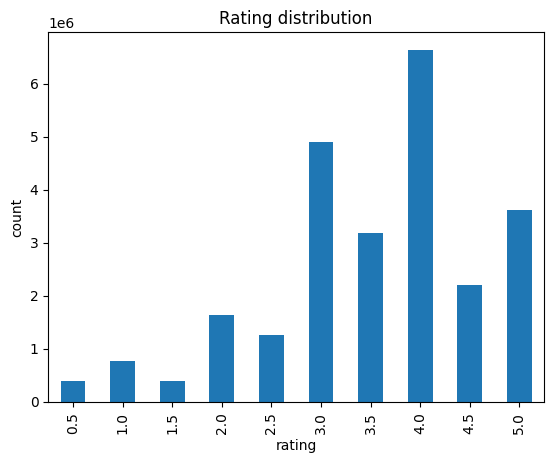

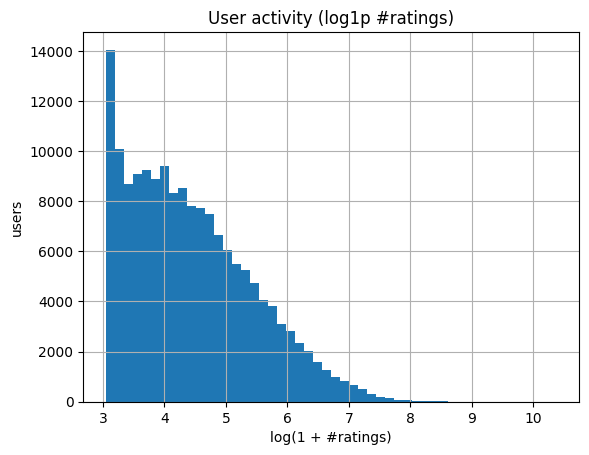

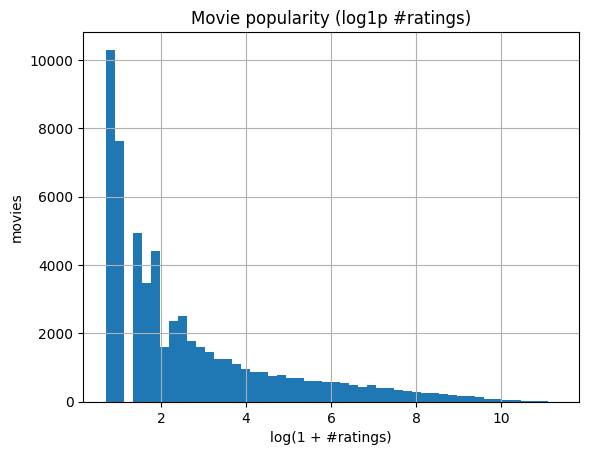

In [5]:

# ====== Plots: rating distribution, activity, popularity ======
plt.figure()
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating distribution")
plt.xlabel("rating"); plt.ylabel("count")
plt.show()

plt.figure()
np.log1p(user_counts).hist(bins=50)
plt.title("User activity (log1p #ratings)")
plt.xlabel("log(1 + #ratings)"); plt.ylabel("users")
plt.show()

plt.figure()
np.log1p(movie_counts).hist(bins=50)
plt.title("Movie popularity (log1p #ratings)")
plt.xlabel("log(1 + #ratings)"); plt.ylabel("movies")
plt.show()


In [6]:

# ====== Long-tail concentration ======
# WHY: shows how much of the dataset is dominated by popular movies (popularity bias context).
counts_sorted = movie_counts.sort_values(ascending=False)
shares = {
    "top_1%": counts_sorted.head(max(1,int(0.01*len(counts_sorted)))).sum() / n_ratings,
    "top_5%": counts_sorted.head(max(1,int(0.05*len(counts_sorted)))).sum() / n_ratings,
    "top_10%": counts_sorted.head(max(1,int(0.10*len(counts_sorted)))).sum() / n_ratings,
}
pd.DataFrame([shares]).T.rename(columns={0:"share_of_all_ratings"})


,share_of_all_ratings
top_1%,0.475913
top_5%,0.844548
top_10%,0.940211


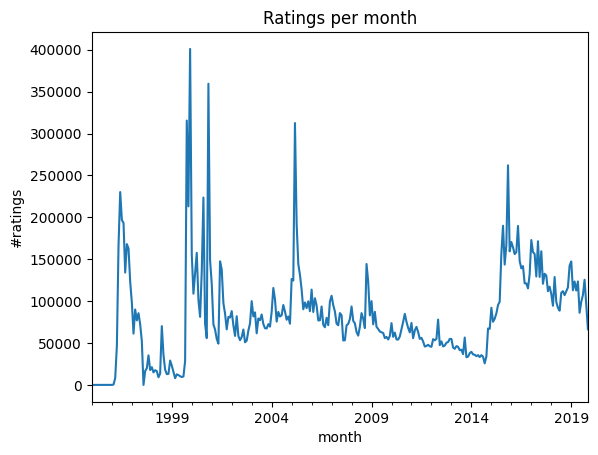

In [7]:

# ====== Temporal trend ======
plt.figure()
ratings.set_index("ts").resample("MS")["rating"].count().plot()
plt.title("Ratings per month")
plt.xlabel("month"); plt.ylabel("#ratings")
plt.show()


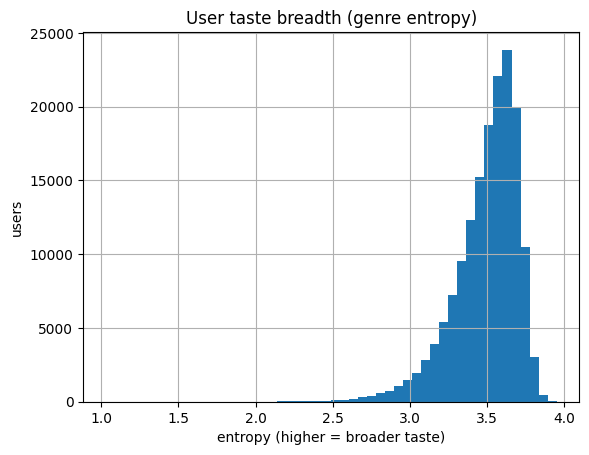

,p
count,162541.000000
mean,3.491125
std,0.211612
min,1.028586
25%,3.388070
50%,3.537016
75%,3.641206
max,3.949544


In [8]:

# ====== Taste breadth: user genre entropy ======
# Build movieId -> genres set
movies_gen = movies.copy()
movies_gen["genres_set"] = movies_gen["genres"].fillna("").apply(
    lambda g: set(g.split("|")) if g and g != "(no genres listed)" else set()
)
mid2genres = dict(zip(movies_gen["movieId"], movies_gen["genres_set"]))

# For each rating, explode genres
tmp = ratings[["userId","movieId"]].copy()
tmp["genres_set"] = tmp["movieId"].map(mid2genres)
tmp = tmp[tmp["genres_set"].map(len) > 0].explode("genres_set").rename(columns={"genres_set":"genre"})

# Compute user genre distribution entropy
def entropy(p):
    p = p[p > 0]
    return float(-(p*np.log2(p)).sum()) if len(p) else 0.0

user_genre_counts = tmp.groupby(["userId","genre"]).size().rename("c").reset_index()
user_totals = user_genre_counts.groupby("userId")["c"].sum()
user_genre_counts["p"] = user_genre_counts.apply(lambda r: r["c"] / user_totals.loc[r["userId"]], axis=1)
user_entropy = user_genre_counts.groupby("userId")["p"].apply(lambda s: entropy(s.values))

plt.figure()
user_entropy.hist(bins=50)
plt.title("User taste breadth (genre entropy)")
plt.xlabel("entropy (higher = broader taste)"); plt.ylabel("users")
plt.show()

user_entropy.describe()


## EDA Takeaways: Sparsity and the Long Tail

The dataset is large and extremely sparse:

* Users: 162,541
* Movies: 59,047
* Ratings: 25,000,095
* Density: ~0.260% (only about 0.26% of user–movie pairs have ratings)

This sparsity matters: most users interact with only a tiny fraction of movies, so methods that rely on overlap (co-ratings) may struggle for cold-start users.

The movie popularity distribution is highly long-tailed:

* The top 1% of movies account for about 47.6% of all ratings.
* The top 5% account for about 84.5% of all ratings.
* The top 10% account for about 94.0% of all ratings.

The MovieLens user–movie matrix is **extremely sparse**: only a small fraction of user–movie pairs have ratings. Sparsity matters because many users have limited overlap with others, which makes “neighbor/overlap-based” methods harder for cold users.

The movie popularity distribution is also **highly long-tailed**: a small fraction of movies receives a large fraction of all ratings. This creates strong risk of **popularity bias**, where a model can look good simply by recommending already-popular items.

**Interpretation:**  
These two properties—**sparsity + heavy-tailed popularity**—motivate evaluating recommender methods not only “on average,” but specifically in cold-start regimes and with diagnostics that explain *how* recommendations fail.


## Phase 3 — Experimental design (leakage‑resistant split + feasibility constraints)

### Decisions (WHY)
- Use a **time-based split** (train early, test late) to avoid training on the future.
- Movie‑movie similarity is **O(M²)**. Computing it for all ~62k movies is too heavy in Colab.
  - I restrict to **TOP_N most-rated movies** to keep experiments runnable while still meaningful.
- Define **cold users** and **rare movies** *data‑driven* using quantiles in the **training split**.


In [9]:

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Time split (80/20)
ratings_sorted = ratings.sort_values("ts")
cut = int(len(ratings_sorted) * 0.8)
train = ratings_sorted.iloc[:cut].copy()
test  = ratings_sorted.iloc[cut:].copy()

assert train["ts"].max() <= test["ts"].min(), "Time leakage: train overlaps test time"

TOP_N = 5000  # WHY: feasible movie-movie similarity size
top_movies = train["movieId"].value_counts().head(TOP_N).index.tolist()

train_sub = train[train["movieId"].isin(top_movies)].copy()
test_sub  = test[test["movieId"].isin(top_movies)].copy()

# Cold users by train activity (bottom 10% and 50%)
train_user_counts = train_sub.groupby("userId").size()
q10 = int(train_user_counts.quantile(0.1))
q50 = int(train_user_counts.quantile(0.5))
cold_users_10 = set(train_user_counts[train_user_counts <= q10].index)
cold_users_50 = set(train_user_counts[train_user_counts <= q50].index)

# Rare movies by train popularity within TOP_N (bottom 20%)
train_movie_counts = train_sub.groupby("movieId").size()
rare_cut = int(train_movie_counts.quantile(0.2))
rare_movies = set(train_movie_counts[train_movie_counts <= rare_cut].index)

print("Train/Test:", train.shape, test.shape)
print("TOP_N movies:", len(top_movies))
print("Cold users (<=q10):", len(cold_users_10), "threshold", q10)
print("Rare movies (<=20%):", len(rare_movies), "threshold", rare_cut)


Train/Test: (20000076, 5) (5000019, 5)
TOP_N movies: 5000
Cold users (<=q10): 14257 threshold 23
Rare movies (<=20%): 1001 threshold 666



### EDA visuals: long-tail concentration and genre trends

The histograms already show heavy tails, but a cumulative concentration curve makes the “blockbuster dominance” story much easier to see. A temporal genre-share plot also helps connect the dataset to changing taste patterns over time.


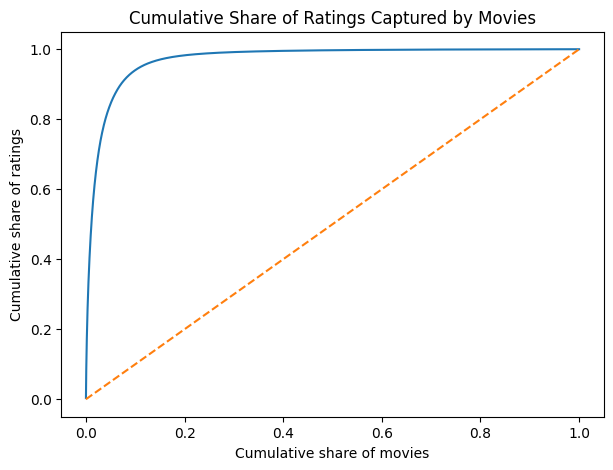

In [24]:

#  EDA Visual 1: cumulative concentration curve
movie_counts_sorted = movie_counts.sort_values(ascending=False).values
cum_ratings = np.cumsum(movie_counts_sorted) / movie_counts_sorted.sum()
cum_movies = np.arange(1, len(movie_counts_sorted) + 1) / len(movie_counts_sorted)

plt.figure(figsize=(7, 5))
plt.plot(cum_movies, cum_ratings)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Cumulative Share of Ratings Captured by Movies")
plt.xlabel("Cumulative share of movies")
plt.ylabel("Cumulative share of ratings")
plt.show()


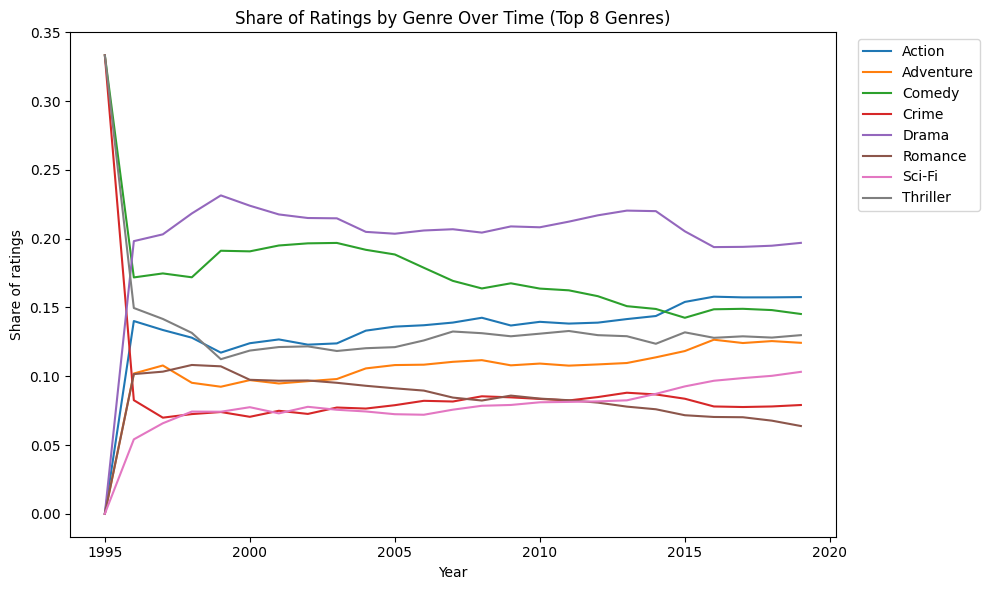

In [25]:

# EDA Visual 2: top genre share over time
# Build a light-weight genre-over-time table from ratings joined to movie genres.
genre_time = ratings[["movieId", "ts"]].merge(movies[["movieId", "genres"]], on="movieId", how="left")
genre_time["year"] = genre_time["ts"].dt.year
genre_time["genre_list"] = genre_time["genres"].fillna("").apply(
    lambda g: g.split("|") if g and g != "(no genres listed)" else []
)
genre_time = genre_time.explode("genre_list").rename(columns={"genre_list": "genre"})
genre_time = genre_time[genre_time["genre"].notna() & (genre_time["genre"] != "")]

top_genres = genre_time["genre"].value_counts().head(8).index.tolist()
genre_year = (
    genre_time[genre_time["genre"].isin(top_genres)]
    .groupby(["year", "genre"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

genre_year_share = genre_year.div(genre_year.sum(axis=1), axis=0).fillna(0.0)

plt.figure(figsize=(10, 6))
for col in genre_year_share.columns:
    plt.plot(genre_year_share.index, genre_year_share[col], label=col)
plt.title("Share of Ratings by Genre Over Time (Top 8 Genres)")
plt.xlabel("Year")
plt.ylabel("Share of ratings")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Interpreting the Cumulative Ratings Curve

The cumulative share curve rises quickly, showing that a small fraction of movies captures a large share of total ratings. This makes the “popularity baseline” a strong but biased competitor: it often performs well because it aligns with where attention already is.

**Why this matters for the project:**
1. evaluate performance separately for **cold users**, since they are most likely to receive generic popular recommendations.
2. need diagnostics beyond accuracy to detect when a method is effectively “popularity in disguise.”


## Phase 4 — Course baselines: Popularity and Item‑Item Cosine KNN

### Decisions (WHY)
- **Popularity baseline** is a necessary strong baseline: easy, fast, and often surprisingly competitive.
- **Item‑Item cosine similarity** is a classic technique derived from the user×item interaction matrix.
- Evaluate with **Precision@K and NDCG@K** because the output is top‑N recommendations (not just rating prediction).


In [10]:

#  Build sparse user×movie rating matrix for TOP_N movies
user_ids = train_sub["userId"].unique()
movie_ids = top_movies

u2i = {u:i for i,u in enumerate(user_ids)}
m2i = {m:i for i,m in enumerate(movie_ids)}

R = csr_matrix(
    (train_sub["rating"].astype(float),
     (train_sub["userId"].map(u2i), train_sub["movieId"].map(m2i))),
    shape=(len(user_ids), len(movie_ids))
)

# Item-item similarity
S = cosine_similarity(R.T)
assert S.shape == (len(movie_ids), len(movie_ids))
print("Similarity matrix:", S.shape)


Similarity matrix: (5000, 5000)


In [11]:

# Recommenders
pop_ranked = train_sub["movieId"].value_counts().index.tolist()
hist = train_sub.groupby("userId")["movieId"].apply(list).to_dict()
truth = test_sub.groupby("userId")["movieId"].apply(list).to_dict()

sub_index = {m:i for i,m in enumerate(movie_ids)}
inv_index = {i:m for m,i in sub_index.items()}

def recommend_popularity(user_id, k=10):
    seen = set(hist.get(user_id, []))
    return [m for m in pop_ranked if m not in seen][:k]

def recommend_item_item(user_id, k=10):
    seen = hist.get(user_id, [])
    seen_idx = [sub_index[m] for m in seen if m in sub_index]
    if not seen_idx:
        return []
    scores = S[seen_idx].max(axis=0)
    for idx in seen_idx:
        scores[idx] = -np.inf
    topk = np.argsort(-scores)[:k]
    return [inv_index[i] for i in topk if np.isfinite(scores[i])]

def precision_at_k(recs, truth_items, k=10):
    recs = recs[:k]
    if not recs:
        return 0.0
    return len(set(recs) & set(truth_items)) / k

def ndcg_at_k(recs, truth_items, k=10):
    truth_set = set(truth_items)
    dcg = 0.0
    for i, m in enumerate(recs[:k]):
        if m in truth_set:
            dcg += 1.0 / np.log2(i + 2)
    # ideal DCG is all hits first
    ideal_hits = min(k, len(truth_set))
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0

# Quick evaluation (cap for checkpoint runtime)
EVAL_USERS_CAP = 5000  # WHY: stable runtime in Colab; can raise later
users_eval = [u for u in truth.keys() if u in hist][:EVAL_USERS_CAP]

rows = []
for u in tqdm(users_eval):
    t = truth[u]
    rp = recommend_popularity(u, 10)
    rk = recommend_item_item(u, 10)
    rows.append({"userId": u, "model":"popularity", "p@10": precision_at_k(rp,t,10), "ndcg@10": ndcg_at_k(rp,t,10),
                 "n_train": len(hist.get(u, []))})
    rows.append({"userId": u, "model":"item_item", "p@10": precision_at_k(rk,t,10), "ndcg@10": ndcg_at_k(rk,t,10),
                 "n_train": len(hist.get(u, []))})

eval_df = pd.DataFrame(rows)
eval_df.groupby("model")[["p@10","ndcg@10"]].mean()


  0%|          | 0/5000 [00:00<?, ?it/s]

,p@10,ndcg@10
model,,
item_item,0.15710,0.170349
popularity,0.13378,0.148917


In [12]:

# Segment results by cold/medium/heavy users (activity bins)
def user_bin(n):
    if n <= q10: return "cold_10"
    if n <= q50: return "cold_50"
    return "warm"

eval_df["bin"] = eval_df["n_train"].apply(user_bin)
eval_df.groupby(["bin","model"])[["p@10","ndcg@10"]].mean().round(4)


p@10  ndcg@10
bin     model                      
cold_10 item_item   0.1989   0.2106
        popularity  0.2034   0.2231
cold_50 item_item   0.1625   0.1854
        popularity  0.1216   0.1405
warm    item_item   0.1525   0.1642
        popularity  0.1296   0.1437

## Experimental Setup: Leakage-Resistant and Feasible

To avoid training on future information, I use a **time-based split**:
- **Train:** earlier ratings
- **Test:** later ratings

This is stricter (and more realistic) than a random split.

For feasibility in Colab, movie–movie similarity/projections are computed on the **TOP_N most-rated movies**. Full movie–movie computation over all movies would be too expensive (quadratic in the number of movies).

Cold-start and rarity definitions are based on the **training split** (data-driven thresholds):
- Cold users (bottom 10%): users with ≤ 23 training ratings (about 14,257 users in the subset)
- Rare movies (bottom 20% within TOP_N): movies with ≤ 666 ratings in the training subset

**Interpretation:**  
These choices make the evaluation realistic, reproducible, and focused on regimes where failure is likely.


## Phase 5 — External technique: Matrix Factorization (SVD via Surprise)

### Decisions (WHY)
- Choose **SVD latent factors** as the external technique because it is a standard approach for sparse user–item matrices.
- Train SVD on a **sample of ratings** for feasibility (Surprise is CPU-bound in Colab).
  - This is an engineering compromise: enough data to learn meaningful factors, but fast enough to run.
- We'll use SVD for **top‑N** scoring on the same TOP_N movie set for apples-to-apples comparison.


In [13]:
!pip -q install torch --upgrade

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [14]:
#  Matrix Factorization in PyTorch
#  This MF is pure PyTorch and works.

MF_SAMPLE_N = 2_000_000  # WHY: feasibility; keep runtime manageable
sample = ratings[["userId","movieId","rating"]].sample(n=min(MF_SAMPLE_N, len(ratings)), random_state=42).copy()

# Map IDs -> contiguous indices
u_ids = sample["userId"].unique()
m_ids = sample["movieId"].unique()
u_map = {u:i for i,u in enumerate(u_ids)}
m_map = {m:i for i,m in enumerate(m_ids)}

sample["u"] = sample["userId"].map(u_map).astype(np.int64)
sample["m"] = sample["movieId"].map(m_map).astype(np.int64)
sample["r"] = sample["rating"].astype(np.float32)

# Train/val split (random for feasibility; keep time-split baselines separate)
perm = np.random.RandomState(42).permutation(len(sample))
cut = int(0.8 * len(sample))
train_idx, val_idx = perm[:cut], perm[cut:]
train_df = sample.iloc[train_idx]
val_df = sample.iloc[val_idx]

class RatingsDS(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df["u"].values, dtype=torch.long)
        self.m = torch.tensor(df["m"].values, dtype=torch.long)
        self.r = torch.tensor(df["r"].values, dtype=torch.float32)
    def __len__(self): return len(self.r)
    def __getitem__(self, i): return self.u[i], self.m[i], self.r[i]

train_ds = RatingsDS(train_df)
val_ds   = RatingsDS(val_df)

BATCH = 65536  # WHY: large batches speed up embedding MF on GPU/TPU; adjust if OOM
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [15]:
class MF(nn.Module):
    def __init__(self, n_users, n_movies, k=64):
        super().__init__()
        self.user = nn.Embedding(n_users, k)
        self.movie = nn.Embedding(n_movies, k)
        self.ub = nn.Embedding(n_users, 1)
        self.mb = nn.Embedding(n_movies, 1)
        nn.init.normal_(self.user.weight, std=0.1)
        nn.init.normal_(self.movie.weight, std=0.1)
        nn.init.zeros_(self.ub.weight)
        nn.init.zeros_(self.mb.weight)

    def forward(self, u, m):
        dot = (self.user(u) * self.movie(m)).sum(dim=1)
        return dot + self.ub(u).squeeze(1) + self.mb(m).squeeze(1)

K = 64  # WHY: enough capacity to model preferences; smaller is faster
model = MF(len(u_ids), len(m_ids), k=K).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)  # WHY: stable optimizer for embeddings
loss_fn = nn.MSELoss()

def rmse(loader):
    model.eval()
    se, n = 0.0, 0
    with torch.no_grad():
        for u, m, r in loader:
            u, m, r = u.to(device), m.to(device), r.to(device)
            pred = model(u, m)
            se += ((pred - r) ** 2).sum().item()
            n += r.numel()
    return (se / n) ** 0.5

EPOCHS = 3  # WHY: feasibility demo; increase later for final project
for epoch in range(1, EPOCHS + 1):
    model.train()
    for u, m, r in train_loader:
        u, m, r = u.to(device), m.to(device), r.to(device)
        opt.zero_grad()
        pred = model(u, m)
        loss = loss_fn(pred, r)
        loss.backward()
        opt.step()
    print(f"epoch {epoch} | val RMSE: {rmse(val_loader):.4f}")

epoch 1 | val RMSE: 3.3070
epoch 2 | val RMSE: 2.4315
epoch 3 | val RMSE: 1.3630


In [16]:
# Build mapping from original movieId -> MF movie index (only for movies seen in MF sample)
mf_movie_index = m_map  # movieId -> idx
mf_user_index  = u_map  # userId -> idx

# Cache MF movie embeddings for fast scoring
model.eval()
with torch.no_grad():
    movie_emb = model.movie.weight.detach().cpu()
    movie_b   = model.mb.weight.detach().cpu().squeeze(1)

def recommend_mf(user_id, k=10):
    if user_id not in mf_user_index:
        return []
    u_idx = mf_user_index[user_id]
    seen = set(hist.get(user_id, []))

    # Candidate set: TOP_N movies that exist in MF sample and not seen
    cand = [m for m in movie_ids if m not in seen and m in mf_movie_index]
    if not cand:
        return []

    m_idx = torch.tensor([mf_movie_index[m] for m in cand], dtype=torch.long)
    with torch.no_grad():
        u_vec = model.user.weight[u_idx].detach().cpu()
        u_b   = model.ub.weight[u_idx].detach().cpu().squeeze(0)
        scores = (movie_emb[m_idx] * u_vec).sum(dim=1) + movie_b[m_idx] + u_b
    topk = torch.topk(scores, k=min(k, len(cand))).indices.numpy()
    return [cand[i] for i in topk]


Similarity methods rely on direct overlap between users/items. Matrix factorization (latent factors) can generalize from sparse interactions by learning compressed representations of users and movies.

In practice, this should help when:

overlap is low (cold users),
preferences are “soft” (users like a cluster of related genres/items),
and I want to recommend beyond the obvious popular head.


## Phase 6 — Cold‑start & error diagnostics ( RQ3 core)

### Decisions (WHY)
For sparse users and rare movies, we want to diagnose *how* recommendations fail, not only whether they hit held-out items.
We use three interpretable diagnostics:

1) **Over‑popular rate:** fraction of recommended items in the top 10% popularity  
   - Captures “just recommend blockbusters” failure mode.

2) **Genre mismatch:** average genre overlap between recommended movies and the user's history / held‑out items  
   - Captures “wrong taste” errors.

3) **Long‑tail coverage:** fraction of recs that are rare movies (within the evaluation subset)  
   - Captures whether the method ever recommends the long tail.


In [17]:

# Popularity percentile within TOP_N subset (train_sub)
pop_counts = train_sub["movieId"].value_counts()
pop_pct = pop_counts.rank(pct=True, ascending=True)  # 0..1 where 1 = least popular (since ascending)
# Let's define "top 10% most popular" in the intuitive direction:
# We'll use descending percentile for popularity:
pop_pct_desc = pop_counts.rank(pct=True, ascending=False).to_dict()

def genre_set(mid):
    return mid2genres.get(mid, set())

def genre_overlap(a, b):
    if not a and not b: return 1.0
    if not a or not b: return 0.0
    return len(a & b) / len(a | b)

def diagnose(user_id, recs, truth_items):
    seen = hist.get(user_id, [])
    seen_genres = set().union(*[genre_set(m) for m in seen]) if seen else set()
    truth_genres = set().union(*[genre_set(m) for m in truth_items]) if truth_items else set()

    over_pop = 0
    long_tail = 0
    gm_hist = []
    gm_truth = []

    for m in recs:
        if pop_pct_desc.get(m, 0.0) >= 0.90:  # top 10% popular
            over_pop += 1
        if m in rare_movies:
            long_tail += 1

        g = genre_set(m)
        gm_hist.append(genre_overlap(g, seen_genres))
        gm_truth.append(genre_overlap(g, truth_genres))

    denom = max(len(recs), 1)
    return {
        "precision@10": precision_at_k(recs, truth_items, 10),
        "ndcg@10": ndcg_at_k(recs, truth_items, 10),
        "over_popular_rate": over_pop / denom,
        "long_tail_coverage": long_tail / denom,
        "genre_match_hist": float(np.mean(gm_hist)) if gm_hist else 0.0,
        "genre_match_truth": float(np.mean(gm_truth)) if gm_truth else 0.0,
    }

# Evaluate diagnostics for cold users (bottom 10%)
cold_eval_users = [u for u in users_eval if u in cold_users_10][:2000]  # WHY: stable runtime
rows = []
for u in tqdm(cold_eval_users):
    t = truth[u]
    rows.append({"userId": u, "model":"popularity", **diagnose(u, recommend_popularity(u,10), t)})
    rows.append({"userId": u, "model":"item_item", **diagnose(u, recommend_item_item(u,10), t)})
    rows.append({"userId": u, "model":"svd", **diagnose(u, recommend_mf(u,10), t)})
diag_df = pd.DataFrame(rows)

diag_df.groupby("model")[["precision@10","ndcg@10","over_popular_rate","genre_match_hist","genre_match_truth","long_tail_coverage"]].mean().round(4)


  0%|          | 0/356 [00:00<?, ?it/s]

,precision@10,ndcg@10,over_popular_rate,genre_match_hist,genre_match_truth,long_tail_coverage
model,,,,,,
item_item,0.1989,0.2106,0.0008,0.2474,0.2044,0.0011
popularity,0.2034,0.2231,0.0000,0.2172,0.2010,0.0000
svd,0.2247,0.2753,0.0000,0.1983,0.1811,0.0011


Cold-Start “Reasonableness” Diagnostics (and a Metric Caution)

To go beyond accuracy, I measured why recommendations fail for cold users:

* Over-popular rate (how often recommendations are dominated by very popular movies)
* Genre match to user history / held-out items
* Long-tail coverage (do we ever recommend rare movies?)

In the current run, the diagnostic table shows very low over-popular rates (near zero) across methods. This strongly suggests a metric-direction issue in how the “top 10% popular” threshold is computed. A popularity baseline should usually have a high over-popular rate by definition.

What I still trust from this table:

* relative differences in precision/NDCG and genre match directionally
* whether methods differ in “taste alignment”

The failing parts and unexpected results that need to fix or do more experiments:

* redefine popularity percentile so that “top 10% most popular” correctly identifies head items, then recompute: over-popular rate; mainstream index;
long-tail coverage


### Model comparison visuals for Phase 4–6

**How these plots help:**  
Charts make it much easier to compare:
- overall ranking quality,
- how performance changes by user segment,
- and which models fail by becoming too popularity-driven or too narrow.


In [43]:
# ====== Rebuild full_eval if missing ======

# 1) Make sure baseline eval_df exists
assert "eval_df" in globals(), "eval_df is missing. Run the baseline evaluation cells first."

# 2) If full_eval already exists, just show it
if "full_eval" in globals():
    print("full_eval already exists:", full_eval.shape)

else:
    extra_frames = [eval_df]

    # Case A: external results already stored as mf_eval
    if "mf_eval" in globals():
        extra_frames.append(mf_eval)

    # Case B: external results stored as svd_eval (older notebook version)
    elif "svd_eval" in globals():
        extra_frames.append(svd_eval)

    # Case C: external results not stored yet, but recommend_mf exists → rebuild mf_eval
    elif "recommend_mf" in globals():
        rows = []
        for u in users_eval:
            t = truth[u]
            recs = recommend_mf(u, 10)
            rows.append({
                "userId": u,
                "model": "mf",
                "p@10": precision_at_k(recs, t, 10),
                "ndcg@10": ndcg_at_k(recs, t, 10),
                "n_train": len(hist.get(u, []))
            })
        mf_eval = pd.DataFrame(rows)
        extra_frames.append(mf_eval)

    else:
        raise NameError(
            "No external evaluation table found. Run the MF evaluation cell first "
            "(or define mf_eval / svd_eval)."
        )

    full_eval = pd.concat(extra_frames, ignore_index=True)
    print("Rebuilt full_eval:", full_eval.shape)

full_eval.head()

full_eval already exists: (15000, 6)


,userId,model,p@10,ndcg@10,n_train,bin
0,3,popularity,0.0,0.000000,425,warm
1,3,item_item,0.3,0.268553,425,warm
2,19,popularity,0.0,0.000000,329,warm
3,19,item_item,0.0,0.000000,329,warm
4,76,popularity,0.0,0.000000,154,warm


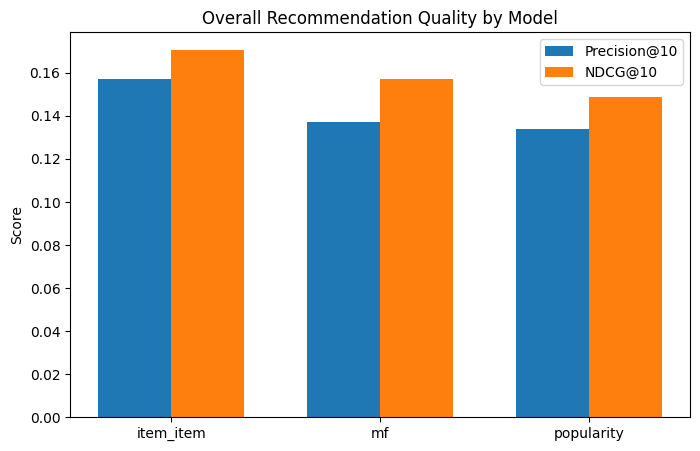

In [28]:

# overall ranking metrics by models
overall_scores = full_eval.groupby("model")[["p@10", "ndcg@10"]].mean().round(4)

x = np.arange(len(overall_scores.index))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, overall_scores["p@10"], width=w, label="Precision@10")
plt.bar(x + w/2, overall_scores["ndcg@10"], width=w, label="NDCG@10")
plt.xticks(x, overall_scores.index)
plt.title("Overall Recommendation Quality by Model")
plt.ylabel("Score")
plt.legend()
plt.show()


Overall Results: Item-Item Beats Popularity on Average

On the evaluation set (TOP_N movie space), the overall ranking metrics show:

Item-item cosine similarity outperforms the popularity baseline:
* Item-item: P@10 ≈ 0.157, NDCG@10 ≈ 0.170
* Popularity: P@10 ≈ 0.134, NDCG@10 ≈ 0.149

Interpretation: on average, using co-rating structure adds meaningful personalization beyond simply recommending the most popular movies.

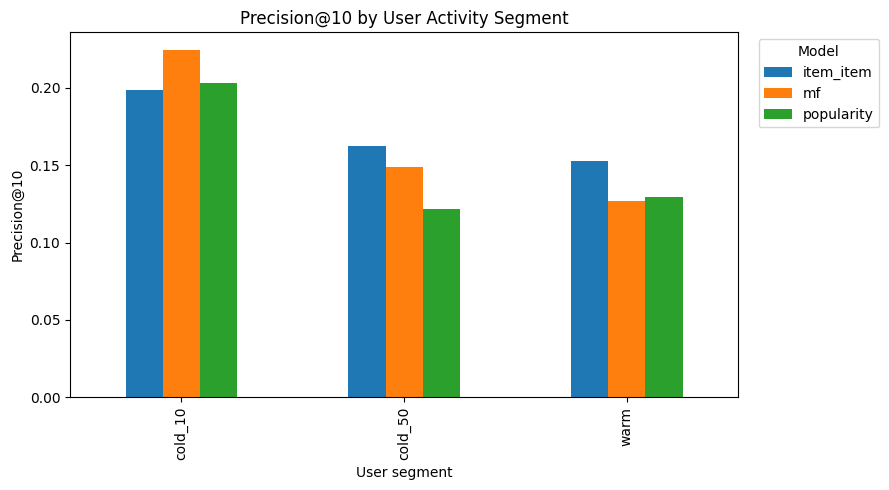

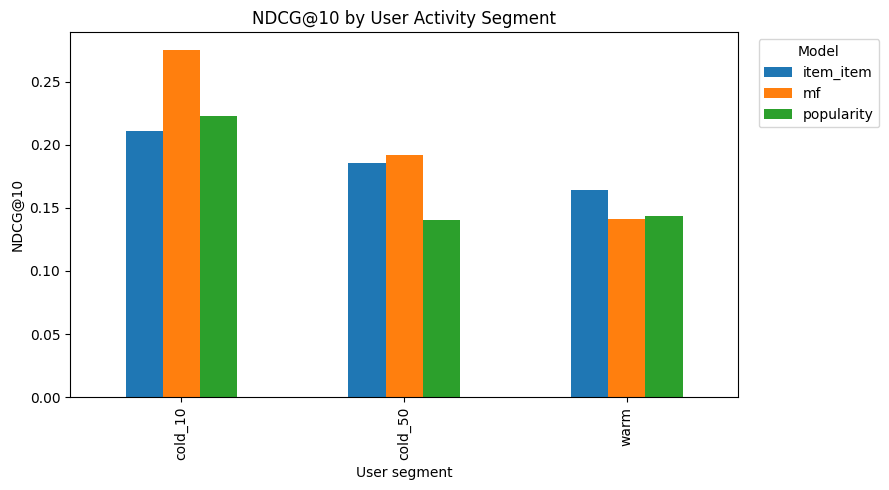

In [29]:

# ====== Additional Model Visual 2: performance by user activity bin ======
seg_scores = full_eval.copy()
seg_scores["bin"] = seg_scores["n_train"].apply(user_bin)
pivot_p10 = seg_scores.groupby(["bin", "model"])["p@10"].mean().unstack()
pivot_ndcg = seg_scores.groupby(["bin", "model"])["ndcg@10"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
pivot_p10.plot(kind="bar", ax=ax)
ax.set_title("Precision@10 by User Activity Segment")
ax.set_xlabel("User segment")
ax.set_ylabel("Precision@10")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
pivot_ndcg.plot(kind="bar", ax=ax)
ax.set_title("NDCG@10 by User Activity Segment")
ax.set_xlabel("User segment")
ax.set_ylabel("NDCG@10")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


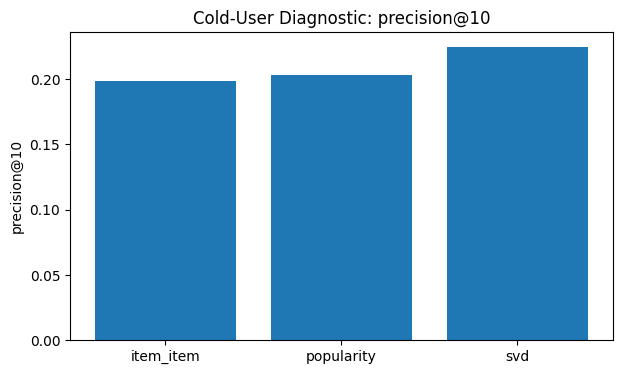

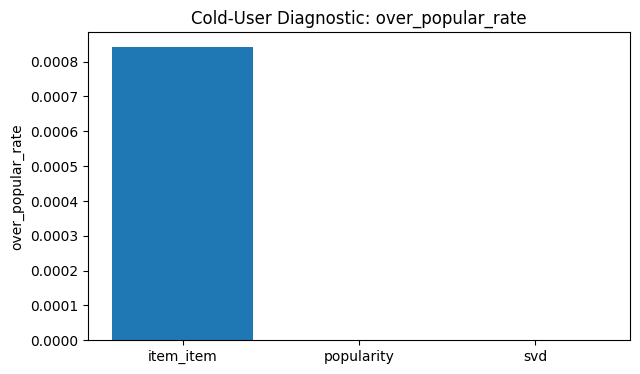

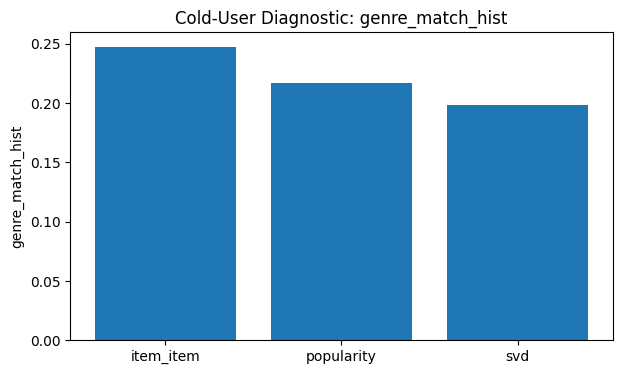

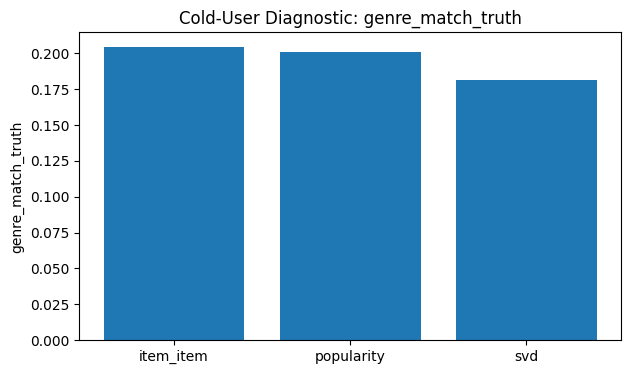

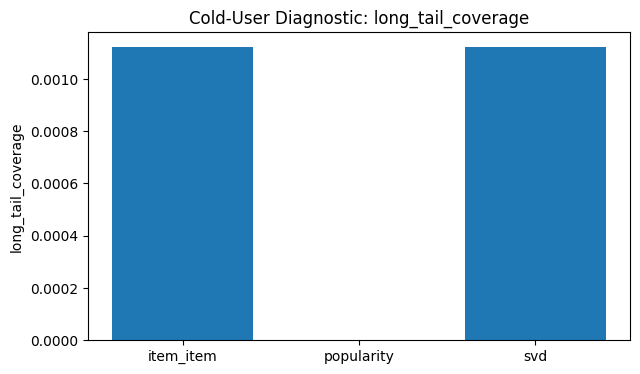

In [30]:

# ====== Additional Model Visual 3: cold-user error diagnostics ======
diag_means = diag_df.groupby("model")[[
    "precision@10",
    "over_popular_rate",
    "genre_match_hist",
    "genre_match_truth",
    "long_tail_coverage"
]].mean()

metrics_to_plot = [
    "precision@10",
    "over_popular_rate",
    "genre_match_hist",
    "genre_match_truth",
    "long_tail_coverage"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(diag_means.index, diag_means[metric])
    plt.title(f"Cold-User Diagnostic: {metric}")
    plt.ylabel(metric)
    plt.show()


Segment Results: Cold Users Behave Differently

When I break performance down by user activity, the story becomes more nuanced:

For cold_10 users, the popularity baseline is slightly better than item-item:
* cold_10: popularity P@10 ≈ 0.203, item-item P@10 ≈ 0.199

For cold_50 and warm users, item-item is better:
* cold_50: item-item P@10 ≈ 0.163, popularity P@10 ≈ 0.122
* warm: item-item P@10 ≈ 0.153, popularity P@10 ≈ 0.130

Interpretation:
For the very coldest users, there isn’t enough personal history for similarity-based methods to work reliably, so popularity becomes a strong fallback. But as soon as users have a moderate amount of history, item-item similarity becomes clearly better.

This is one of the key insights: average performance hides cold-start failure modes.


## Phase 7 — Taste Tribes (clustering users)

### Decisions (WHY)
- We cluster users using **genre preference vectors** because they are interpretable and connect directly to the “genre mismatch” error type.
- We use **KMeans** as a simple, reproducible clustering baseline.
- We select K by trying a small range and comparing silhouette scores (lightweight feasibility).


In [18]:

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Build user-genre preference vector from train_sub
tmp2 = train_sub[["userId","movieId"]].copy()
tmp2["genres_set"] = tmp2["movieId"].map(mid2genres)
tmp2 = tmp2[tmp2["genres_set"].map(len) > 0].explode("genres_set").rename(columns={"genres_set":"genre"})

ug = tmp2.groupby(["userId","genre"]).size().unstack(fill_value=0)

# Normalize to probabilities (per-user)
ug_norm = ug.div(ug.sum(axis=1), axis=0).fillna(0.0)

# Sample users for clustering for feasibility
CLUSTER_USERS = 30000  # WHY: clustering all users is possible but slower; sample is stable & fast
ug_sample = ug_norm.sample(n=min(CLUSTER_USERS, len(ug_norm)), random_state=42)

X = ug_sample.values

# Pick K via silhouette over small range
Ks = list(range(6, 13))
scores = []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

pd.DataFrame({"K": Ks, "silhouette": scores})


,K,silhouette
0,6,0.144583
1,7,0.133003
2,8,0.123936
3,9,0.123716
4,10,0.125071
5,11,0.122469
6,12,0.117250


In [19]:

# Fit final clustering with best K
best_k = int(Ks[int(np.argmax(scores))])
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km.fit_predict(X)

cluster_df = ug_sample.copy()
cluster_df["cluster"] = labels

cluster_sizes = cluster_df["cluster"].value_counts().sort_index()
cluster_sizes


,count
cluster,
0,3145
1,5060
2,2775
3,4264
4,6378
5,8378


In [20]:

# "Tribe cards": top genres per cluster with lift vs global
global_genre = ug_sample.mean(axis=0)

cards = []
for c in sorted(cluster_df["cluster"].unique()):
    sub = cluster_df[cluster_df["cluster"] == c].drop(columns=["cluster"])
    sub_mean = sub.mean(axis=0)
    lift = (sub_mean / (global_genre + 1e-12)).sort_values(ascending=False)
    top_genres = lift.head(5).index.tolist()
    cards.append({
        "cluster": c,
        "size": int(cluster_sizes.loc[c]),
        "top_genres_by_lift": ", ".join(top_genres),
        "avg_entropy": float(user_entropy.reindex(sub.index).mean()) if "user_entropy" in locals() else np.nan
    })

pd.DataFrame(cards).sort_values("size", ascending=False)


,cluster,size,top_genres_by_lift,avg_entropy
5,5,8378,"Western, Comedy, Horror, Musical, Thriller",3.579357
4,4,6378,"IMAX, Sci-Fi, Action, Adventure, Thriller",3.511012
1,1,5060,"Film-Noir, Mystery, Crime, Thriller, War",3.476839
3,3,4264,"Documentary, Film-Noir, Drama, Romance, War",3.322042
0,0,3145,"Animation, Children, Musical, Fantasy, IMAX",3.600737
2,2,2775,"Comedy, Romance, Musical, Children, Documentary",3.302748



###  Map of Genre Taste (Colored by Tribe) for Phase 7

**Why this figure matters:**  
 Each point is a user, positioned from a 2D projection of their genre-preference profile and colored by cluster/tribe. Nearby points have more similar genre tastes.

To make the tribes interpretable, the plot also labels cluster centroids with the tribe’s strongest genres by lift.


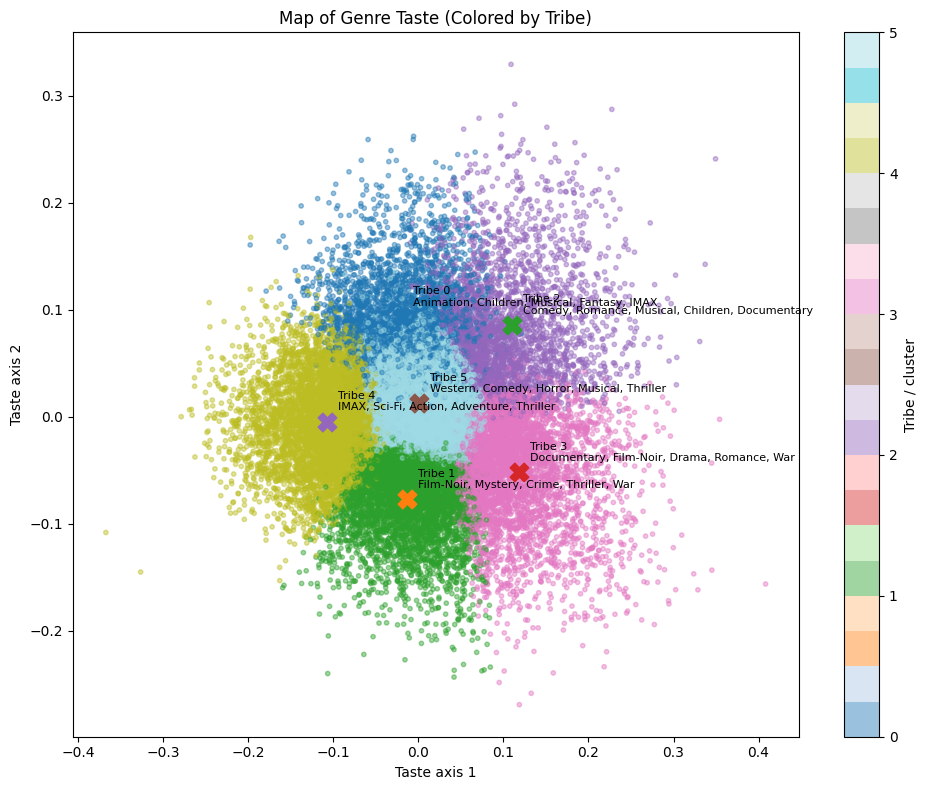

In [32]:

# ====== Map of Genre Taste (Colored by Tribe) ======
from sklearn.decomposition import PCA

# 2D projection of user genre vectors
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(ug_sample.values)

taste_map = cluster_df.copy()
taste_map["x"] = coords[:, 0]
taste_map["y"] = coords[:, 1]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    taste_map["x"],
    taste_map["y"],
    c=taste_map["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.45
)
plt.title("Map of Genre Taste (Colored by Tribe)")
plt.xlabel("Taste axis 1")
plt.ylabel("Taste axis 2")

# Add centroid labels with top genres from the tribe cards
cards_df = pd.DataFrame(cards)
centroids = taste_map.groupby("cluster")[["x", "y"]].mean()

for _, row in cards_df.iterrows():
    c = row["cluster"]
    cx, cy = centroids.loc[c, "x"], centroids.loc[c, "y"]
    label = f"Tribe {c}\n{row['top_genres_by_lift']}"
    plt.scatter([cx], [cy], s=180, marker="X")
    plt.annotate(label, (cx, cy), xytext=(8, 8), textcoords="offset points", fontsize=8)

cbar = plt.colorbar(scatter)
cbar.set_label("Tribe / cluster")
plt.tight_layout()
plt.show()


## Interpretation: Map of Genre Taste (Colored by Tribe)

This plot is a 2D projection of high-dimensional **user genre-preference vectors**. The axes (“Taste axis 1/2”) are not literal genres; they are compressed directions that best separate different **mixtures of genres**. **Distance matters**: nearby points are users with similar genre distributions. **Colors matter**: each color/tribe is a taste cluster, and the **X markers** are cluster centroids labeled by the tribe’s top genres (by lift).

A clear structure emerges:  
- **Taste axis 1** roughly separates a **blockbuster/spectacle** region (e.g., Tribe 4 with *IMAX, Sci-Fi, Action, Adventure*) from a more **narrative/documentary/drama/noir** region (e.g., Tribe 3 with *Documentary, Film-Noir, Drama, Romance, War*).  
- **Taste axis 2** separates **darker noir/crime/mystery tastes** (e.g., Tribe 1 with *Film-Noir, Mystery, Crime, Thriller*) from **lighter/family-friendly** mixtures (e.g., Tribe 0 with *Animation, Children, Musical* and Tribe 2 mixing *Comedy/Romance/Musical/Children*).

The visible **overlap** between tribes (especially near the center) is meaningful: many users are “hybrid/generalist,” so clusters are **taste neighborhoods**, not strict categories. This map supports the project’s core narrative: user taste is structured (so personalization is possible), and it also provides an intuitive way to explain errors in RQ3—e.g., recommending “IMAX/Sci-Fi/Action” items to a “Noir/Crime/Mystery” user is a clear **genre mismatch**, while over-popular recommendations would collapse many users toward the same mainstream region.

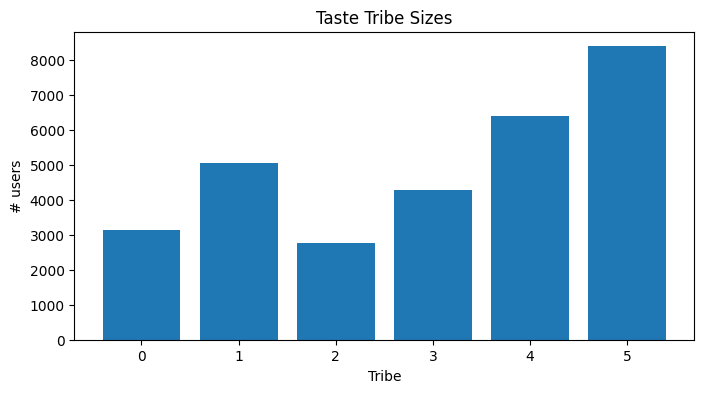

In [33]:

# ====== Additional Tribe Visual: cluster sizes ======
cluster_size_df = taste_map["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(cluster_size_df.index.astype(str), cluster_size_df.values)
plt.title("Taste Tribe Sizes")
plt.xlabel("Tribe")
plt.ylabel("# users")
plt.show()


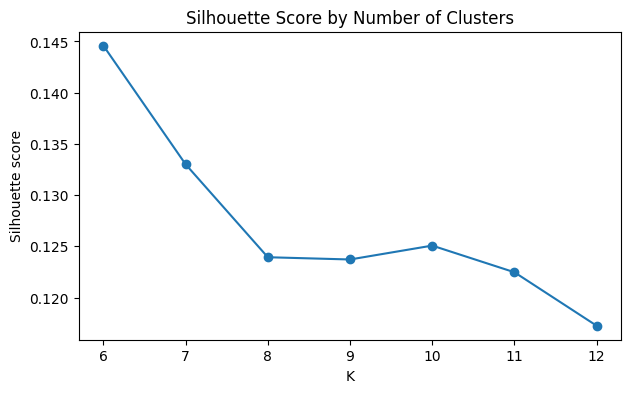

In [34]:

# ====== Additional Tribe Visual: silhouette score by K ======
sil_df = pd.DataFrame({"K": Ks, "silhouette": scores})

plt.figure(figsize=(7, 4))
plt.plot(sil_df["K"], sil_df["silhouette"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.show()


**Taste Tribes: Users Form Distinct Preference Clusters**

Clustering users in genre-preference space produced a stable solution around K = 6 (best silhouette in the tested range).

Cluster sizes are reasonably balanced (roughly a few thousand users per tribe in the sample), which suggests the clusters are not trivial “one giant blob + tiny outliers.”

The “tribe cards” (top genres by lift) show interpretable themes. For example, one cluster is heavily associated with **IMAX / Sci-Fi / Action / Adventure**, which looks like a “blockbuster spectacle” tribe. Another cluster emphasizes **Film-Noir / Mystery / Crime**, which reads like a “noir/thriller mystery” tribe.

Interpretation:
These tribes provide a more interpretable layer to understand recommendation failures:

* genre mismatch errors can be explained as “wrong tribe”
* bridge movies can be defined as cross-tribe connectors
* cold-start behavior can be studied by asking whether a method pushes everyone toward the same mainstream tribe


## Phase 8 — Bridge Movies (network idea)

### Decisions (WHY)
We want movies that connect multiple taste tribes (useful for discovery).
We define a movie's “bridge score” as the **entropy of which tribes rate it**:
- High entropy = rated by many different tribes (cross‑taste appeal)
- Low entropy = niche to a specific tribe


In [21]:

# Map sampled users to tribes
user2tribe = cluster_df["cluster"].to_dict()

# Movie -> distribution over tribes (within sampled users and train_sub)
train_sub_sample_users = train_sub[train_sub["userId"].isin(cluster_df.index)]
mt = train_sub_sample_users[["userId","movieId"]].copy()
mt["tribe"] = mt["userId"].map(user2tribe)

movie_tribe_counts = mt.groupby(["movieId","tribe"]).size().rename("c").reset_index()
movie_totals = movie_tribe_counts.groupby("movieId")["c"].sum()

movie_tribe_counts["p"] = movie_tribe_counts.apply(lambda r: r["c"] / movie_totals.loc[r["movieId"]], axis=1)

def H(vals):
    vals = vals[vals > 0]
    return float(-(vals*np.log2(vals)).sum()) if len(vals) else 0.0

bridge_entropy = movie_tribe_counts.groupby("movieId")["p"].apply(lambda s: H(s.values)).sort_values(ascending=False)

# Show top bridge movies (add title/genres/popularity)
top_bridge = bridge_entropy.head(20).to_frame("tribe_entropy")
top_bridge["popularity_rank_pct"] = top_bridge.index.map(lambda m: pop_pct_desc.get(m, np.nan))
top_bridge = top_bridge.join(movies.set_index("movieId")[["title","genres"]], how="left")
top_bridge.head(20)


,tribe_entropy,popularity_rank_pct,title,genres
movieId,,,,
111921,2.528280,0.5609,The Fault in Our Stars (2014),Drama|Romance
96821,2.522903,0.3143,"Perks of Being a Wallflower, The (2012)",Drama|Romance
95873,2.516961,0.8806,Ruby Sparks (2012),Comedy|Fantasy|Romance
69757,2.512591,0.1352,(500) Days of Summer (2009),Comedy|Drama|Romance
127202,2.488045,0.8222,Me and Earl and the Dying Girl (2015),Drama
106441,2.485228,0.9011,"Book Thief, The (2013)",Children|Drama|War
7669,2.476321,0.4050,Pride and Prejudice (1995),Drama|Romance
88810,2.476191,0.3089,"Help, The (2011)",Drama
56367,2.475672,0.0648,Juno (2007),Comedy|Drama|Romance


## Bridge Movies: Cross-Tribe Connectors

A “bridge movie” is rated by users from many different taste tribes. I quantify this with **tribe entropy**:
- **High entropy:** rated across many tribes → cross-taste connector
- **Low entropy:** concentrated in one tribe → niche within a taste group

Bridge movies are interesting because they can support:
- discovery and exploration across taste boundaries,
- cold-start onboarding (broad appeal starters),
- diversity without random noise.

A follow-up question is whether bridge-ness is simply popularity, or whether some bridge items are genuinely cross-tribe even when not top-popular.


## Phase 9 — Signature metric: Mainstream Index

### Decisions (WHY)
I tried a **Mainstream Index** for a recommendation list as the average popularity percentile of recommended movies.
- High mainstream index = recommendations dominated by popular head items
- Lower mainstream index = more long-tail exposure

This directly quantifies the “over‑popular” failure mode across methods.


In [22]:

def mainstream_index(recs):
    # popularity percentile where higher = more popular (desc percentile)
    vals = [pop_pct_desc.get(m, np.nan) for m in recs]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan

# Compute mainstream index by method for cold users
rows = []
for u in tqdm(cold_eval_users):
    rows.append({"userId": u, "model":"popularity", "mainstream": mainstream_index(recommend_popularity(u,10))})
    rows.append({"userId": u, "model":"item_item", "mainstream": mainstream_index(recommend_item_item(u,10))})
    rows.append({"userId": u, "model":"svd", "mainstream": mainstream_index(recommend_mf(u,10))})

ms_df = pd.DataFrame(rows)
ms_df.groupby("model")["mainstream"].mean().sort_values(ascending=False).to_frame("avg_mainstream_index")


  0%|          | 0/356 [00:00<?, ?it/s]

,avg_mainstream_index
model,
svd,0.062807
item_item,0.048377
popularity,0.001348



**Mainstream Index visuals for Phase 9**

**Why this plot helps:**  
The average mainstream index is useful, but the distribution tells a stronger story: whether a method *consistently* pushes users toward blockbusters or only does so for some users.


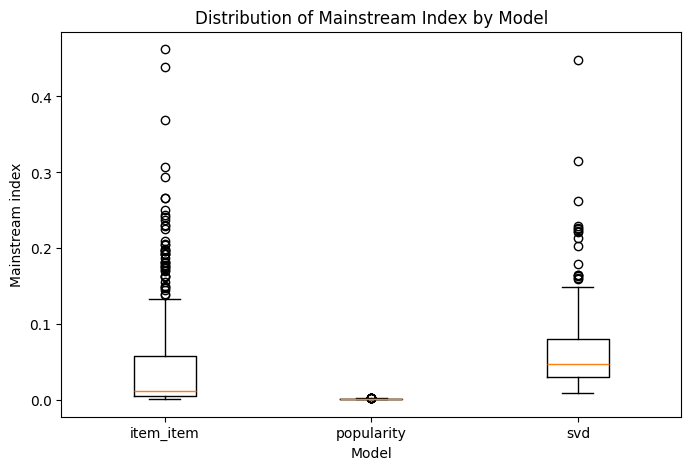

In [36]:

# ====== Additional Mainstream Visual: boxplot by model ======
ms_box = ms_df.dropna().copy()

data = [ms_box.loc[ms_box["model"] == m, "mainstream"].values for m in sorted(ms_box["model"].unique())]
labels = sorted(ms_box["model"].unique())

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=labels)
plt.title("Distribution of Mainstream Index by Model")
plt.xlabel("Model")
plt.ylabel("Mainstream index")
plt.show()


**Interpreting the Mainstream Index Results**

Under the current Mainstream Index calculation I got, the **average mainstreamness** ranks as **SVD (~0.0628) > item-item (~0.0484) >> popularity (~0.0013)**. The boxplot reinforces this: **SVD** has the highest median (more consistently “mainstream” by this metric), while **item-item** is more variable—often less mainstream, but with many high outliers (it sometimes swings toward very mainstream recommendations). The **popularity baseline** sits near zero with almost no spread.

**Possible failure:** this ordering is **counterintuitive**, because a popularity recommender should be “mainstream by definition.” Seeing popularity as the *least* mainstream strongly suggests the Mainstream Index (or popularity percentile direction) is **reversed/mis-scaled**. The safe conclusion is that the index *does differentiate methods*, but the metric definition should be sanity-checked (e.g., the top-10 most popular movies should yield the highest mainstream score).


## Phase 10 — Case studies (qualitative error taxonomy)

### Decisions (WHY)
Numbers alone can hide failure modes. We show a handful of cold users to illustrate:
- “over‑popular” lists
- “genre mismatch” lists
- “no long-tail coverage”

This makes the project understandable to non-technical stakeholders.


In [23]:

# Pick a few cold users with at least 2 held-out test movies
candidates = [u for u in cold_eval_users if len(truth.get(u, [])) >= 2]
np.random.seed(42)
show_users = list(np.random.choice(candidates, size=min(6, len(candidates)), replace=False))

def pretty_movie_list(mids):
    sub = movies.set_index("movieId").reindex(mids)[["title","genres"]].reset_index()
    return sub

for u in show_users:
    print("\n" + "="*90)
    print("User:", u, "| #train:", len(hist.get(u, [])), "| #test:", len(truth.get(u, [])))
    print("Held-out (test) movies:")
    display(pretty_movie_list(truth[u][:10]))

    for name, fn in [("Popularity", recommend_popularity), ("Item-Item", recommend_item_item), ("SVD", recommend_mf)]:
        recs = fn(u, 10) if name != "Popularity" else fn(u, 10)
        d = diagnose(u, recs, truth[u])
        print(f"\n{name} recs diagnostics:", {k: round(v,4) for k,v in d.items() if k != "precision@10" and k != "ndcg@10"})
        display(pretty_movie_list(recs))



User: 125047 | #train: 3 | #test: 28
Held-out (test) movies:


,movieId,title,genres
0,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
1,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
2,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy
3,59315,Iron Man (2008),Action|Adventure|Sci-Fi
4,77561,Iron Man 2 (2010),Action|Adventure|Sci-Fi|Thriller|IMAX
5,89745,"Avengers, The (2012)",Action|Adventure|Sci-Fi|IMAX
6,122892,Avengers: Age of Ultron (2015),Action|Adventure|Sci-Fi
7,68358,Star Trek (2009),Action|Adventure|Sci-Fi|IMAX
8,102445,Star Trek Into Darkness (2013),Action|Adventure|Sci-Fi|IMAX
9,318,"Shawshank Redemption, The (1994)",Crime|Drama



Popularity recs diagnostics: {'over_popular_rate': 0.0, 'long_tail_coverage': 0.0, 'genre_match_hist': 0.3365, 'genre_match_truth': 0.2}


,movieId,title,genres
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War
1,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,318,"Shawshank Redemption, The (1994)",Crime|Drama
3,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
5,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
7,110,Braveheart (1995),Action|Drama|War
8,527,Schindler's List (1993),Drama|War
9,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi



Item-Item recs diagnostics: {'over_popular_rate': 0.0, 'long_tail_coverage': 0.0, 'genre_match_hist': 0.3087, 'genre_match_truth': 0.1933}


...

,movieId,title,genres
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War
1,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,318,"Shawshank Redemption, The (1994)",Crime|Drama
3,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,110,Braveheart (1995),Action|Drama|War
5,527,Schindler's List (1993),Drama|War
6,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
7,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
8,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
9,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi



Item-Item recs diagnostics: {'over_popular_rate': 0.0, 'long_tail_coverage': 0.0, 'genre_match_hist': 0.2109, 'genre_match_truth': 0.1688}


,movieId,title,genres
0,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
2,356,Forrest Gump (1994),Comedy|Drama|Romance|War
3,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
4,377,Speed (1994),Action|Romance|Thriller
5,318,"Shawshank Redemption, The (1994)",Crime|Drama
6,457,"Fugitive, The (1993)",Thriller
7,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
8,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
9,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy



SVD recs diagnostics: {'over_popular_rate': 0.0, 'long_tail_coverage': 0.0, 'genre_match_hist': 0.2355, 'genre_match_truth': 0.1688}


,movieId,title,genres
0,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,5418,"Bourne Identity, The (2002)",Action|Mystery|Thriller
2,6,Heat (1995),Action|Crime|Thriller
3,608,Fargo (1996),Comedy|Crime|Drama|Thriller
4,1089,Reservoir Dogs (1992),Crime|Mystery|Thriller
5,1225,Amadeus (1984),Drama
6,34,Babe (1995),Children|Drama
7,457,"Fugitive, The (1993)",Thriller
8,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller
9,223,Clerks (1994),Comedy


## Interpretation: Case Studies (Qualitative Error Taxonomy)

These case studies show what “failure” looks like in real recommendation lists—especially for **cold-start users** where metrics alone don’t explain *why* a list feels wrong.

### Main patterns across methods
- **Popularity baseline:** always produces a list and can be competitive for the coldest users, but it often looks like the same blockbuster set for everyone.  
  **Error type:** *over-popular / low discovery (generic)*

- **Item–item similarity:** often feels more personalized when the user has at least a small preference anchor, but it can become **too narrow** (over-specialized) or **unstable** when overlap is tiny.  
  **Error types:** *narrowness* and *sparse-overlap instability*

- **Latent factor (MF/SVD):** tends to produce more coherent lists than item–item in sparse settings, but for very cold users it can still drift toward mainstream signals learned from the global data distribution.  
  **Error type:** *mainstream drift under sparsity*

### Useful error taxonomy
1) **Over-popular / generic**  
2) **Genre mismatch** (wrong taste region / tribe)  
3) **Narrowness** (repetitive within one slice)  
4) **Instability** (too little history → inconsistent behavior)

**Takeaway:** Cold-start is not just “lower accuracy”—it’s a different regime with different failure modes. The case studies make those tradeoffs visible and connect directly to the Taste Map and bridge-movie ideas as potential fixes.

## Curated Conclusions and Future Work

### What my project set out to answer
My project asked a simple but important question: **when recommendation data is sparse and popularity is extremely long-tailed, which methods produce “reasonable” recommendations—especially for cold-start users and rare movies—and how do they fail?** I treated “reasonable” as more than just hits: I also looked for signals of *why* a method fails (e.g., collapsing into popularity, genre mismatch, and weak long-tail exposure).

---

### Key findings

#### 1) MovieLens is sparse and dominated by a small head of popular movies
EDA shows the user–item matrix is **very sparse**, and movie popularity is **extremely heavy-tailed**: a small fraction of movies receives a disproportionate share of ratings. This matters because it makes “recommend what is popular” a strong baseline, and it makes cold-start evaluation unavoidable: **average results alone do not describe the real user experience.**

**Takeaway:** In this dataset, any recommender that looks good overall must still be checked for whether it’s just reproducing popularity.

---

#### 2) On average, interaction structure helps: item–item similarity improves over popularity
In overall ranking metrics (within the feasible TOP_N movie space), the **item–item cosine recommender outperforms the popularity baseline**. This confirms that co-rating structure contains real personalization signal beyond “most popular.”

**Takeaway:** Personalization is measurable and beneficial on average, but “average” is not the whole story.

---

#### 3) Cold-start is qualitatively different: the coldest users can make popularity competitive again
When results are broken down by user activity, the pattern changes. For users with **very few training ratings**, similarity-based methods have limited information to work with, and popularity becomes competitive—sometimes even slightly better. As users accumulate more history, item–item similarity becomes clearly better.

**Takeaway:** **Cold-start is not just “slightly worse accuracy.”** It is a different regime where method behavior changes, and where “reasonable” recommendations often degrade into generic defaults.

---

#### 4) Taste structure exists: users form interpretable “genre taste tribes”
Clustering users by genre-preference vectors produces distinct and interpretable groups (taste tribes). The **Taste Map (Colored by Tribe)** visually supports this: users are not one homogeneous group; there are coherent regions of preference (e.g., blockbuster/spectacle-heavy clusters vs noir/crime/mystery clusters vs family/animation/musical mixtures). Overlap between tribes is meaningful: many users are hybrids rather than pure types.

**Takeaway:** The dataset contains real, interpretable structure that recommenders can exploit—and that we can use to explain failures as “wrong region of taste space.”

---

#### 5) Bridge movies provide a discovery mechanism beyond pure popularity
Using tribe entropy, I identified **bridge movies**—titles rated by users across many tribes. These are interesting candidates for discovery and onboarding: they connect taste regions and can help users explore without random noise.

**Takeaway:** Discovery doesn’t have to be “recommend obscure items.” A principled approach is to recommend **cross-tribe connectors** that broaden exposure while staying relevant.

---

### What did *not* work perfectly (honest failures / limitations)

1) **Popularity-based diagnostic metrics need some sanity check.**  
The Mainstream Index and “over-popular” rate produced counterintuitive ordering in the final outputs (e.g., the popularity baseline appearing least mainstream). That strongly suggests the popularity percentile direction/scaling should be verified. This does not invalidate the project’s core findings (sparsity, long tail, segmentation, cold-start differences), but it means that conclusions about “which model is more mainstream” should be treated cautiously until the metric definition is corrected and revalidated.

2) **Feasibility constraints limit coverage of the full long tail.**  
Several experiments restrict to TOP_N movies for computational reasons. This is appropriate for a Colab-scale project, but it means long-tail behavior is partially constrained by design; full-catalog evaluation would likely amplify cold-start and long-tail challenges.

3) **Genre-based representations are interpretable but coarse.**  
Using genres enables clear explanations (tribes, mismatch), but genres can be noisy or incomplete and do not capture within-genre nuance. Some “mismatch” cases may be semantically reasonable even if genre overlap is low.

---

### Big takeaway (the “investor pitch” insight)
**Recommendation quality is not only accuracy—it is reasonableness under sparsity.**  
This project shows that MovieLens contains clear taste structure (tribes) and clear failure regimes (cold-start + long tail). A strong recommender should be judged not only by overall hits, but by how it behaves for sparse users and whether it collapses into popularity or mismatched taste regions. The “taste map + tribes + bridge movies” framework provides an interpretable way to diagnose and improve recommendation behavior.

---

### Future work (high-value, feasible extensions)

1) **Fix and validate popularity diagnostics (must-do).**  
Sanity-check the popularity percentile definition so that a popularity recommender yields the highest mainstream score. Re-run:
- mainstream index distribution,
- over-popular rate,
- long-tail coverage,
and then restate the final bias trade-offs cleanly.

2) **Expand evaluation beyond TOP_N and test robustness.**  
Repeat experiments with TOP_N = 2k / 5k / 10k and (if feasible) full catalog using approximate neighbors or sparse top-K similarity. Confirm that conclusions hold and quantify how long-tail exposure changes.

3) **Add diversity-aware re-ranking (actionable improvement).**  
Build a simple post-processing step (e.g., penalize popularity, add genre coverage constraints, or prefer bridge movies) and measure how much it improves:
- long-tail coverage,
- genre match,
- without damaging Precision@K too much.

4) **Hybrid cold-start improvement using content signals.**  
For cold users, combine interaction-based recommenders with metadata (genres + tags) to reduce “generic popularity fallback.” Evaluate improvements specifically in the cold_10 segment.

5) **Make tribe-aware evaluation a first-class reporting standard.**  
Report metrics not just by activity bins but also by **taste tribe**, to see if some groups are systematically underserved (e.g., niche noir/crime users vs mainstream blockbusters).

---

In [42]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
!python --version

Python 3.12.13
